# NutriClass: Food Classification Using Nutritional Data

## Objective
To develop a multi-class machine learning model that predicts the exact food name based on nutritional attributes such as calories, protein, fat, carbohydrates, and other dietary metrics.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv(r"C:\Users\gomathi.srinivasan\OneDrive - Accenture\Documents\Nutition_food\dataset\synthetic_food_dataset_imbalanced.csv")
df.head()


,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size,Meal_Type,Preparation_Method,Is_Vegan,Is_Gluten_Free,Food_Name
0,290.463673,14.340084,14.152608,35.266644,4.828030,1.291432,647.553389,24.990309,81.575896,45.669118,197.570043,dinner,fried,False,False,Pizza
1,212.626748,4.080908,11.621584,23.218957,16.347814,0.130303,68.572414,34.301652,69.522492,49.854415,103.833510,snack,raw,False,True,Ice Cream
2,330.695408,14.326708,19.747680,29.479164,6.251137,0.794477,663.171859,34.816834,62.552384,40.132866,198.989367,snack,raw,False,False,Burger
3,198.070798,9.452445,5.475896,32.097878,2.984621,1.710468,300.749543,28.510998,68.688853,57.423461,135.714202,lunch,fried,False,True,Sushi
4,274.496228,6.099547,16.256002,29.756638,17.352958,1.465676,296.314958,15.403173,70.385059,33.170460,73.019474,snack,baked,False,False,Donut


In [3]:
df.shape

(31700, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31700 entries, 0 to 31699
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Calories            31325 non-null  float64
 1   Protein             31325 non-null  float64
 2   Fat                 31325 non-null  float64
 3   Carbs               31325 non-null  float64
 4   Sugar               31325 non-null  float64
 5   Fiber               31325 non-null  float64
 6   Sodium              31325 non-null  float64
 7   Cholesterol         31325 non-null  float64
 8   Glycemic_Index      31325 non-null  float64
 9   Water_Content       31325 non-null  float64
 10  Serving_Size        31325 non-null  float64
 11  Meal_Type           31700 non-null  object 
 12  Preparation_Method  31700 non-null  object 
 13  Is_Vegan            31700 non-null  bool   
 14  Is_Gluten_Free      31700 non-null  bool   
 15  Food_Name           31700 non-null  object 
dtypes: b

In [5]:
df.describe()

,Calories,Protein,Fat,Carbs,Sugar,Fiber,Sodium,Cholesterol,Glycemic_Index,Water_Content,Serving_Size
count,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000,31325.000000
mean,273.378441,9.523802,12.476848,28.943200,8.543813,1.904044,335.387611,26.865167,64.213509,48.976592,150.731940
std,111.457160,8.024212,8.425834,12.668795,7.989075,1.779542,319.066106,24.965067,25.390239,20.738749,51.796599
min,60.786204,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.465039,58.575705
25%,210.301731,3.858307,8.245636,25.098800,3.739656,0.741204,63.000654,12.701920,59.984731,38.994221,109.511113
50%,281.774249,9.091637,11.574161,29.681430,5.500479,1.646608,292.525242,23.285882,68.436204,45.613748,151.706514
75%,329.821946,12.683957,15.818611,34.635789,14.426303,2.668750,631.367901,35.132214,75.464697,52.399496,189.083806
max,1289.956763,81.761772,88.619611,140.585537,78.548162,18.891993,2724.236846,260.149443,286.126400,251.837472,554.719629


In [6]:
df.isnull().sum()

Calories              375
Protein               375
Fat                   375
Carbs                 375
Sugar                 375
Fiber                 375
Sodium                375
Cholesterol           375
Glycemic_Index        375
Water_Content         375
Serving_Size          375
Meal_Type               0
Preparation_Method      0
Is_Vegan                0
Is_Gluten_Free          0
Food_Name               0
dtype: int64

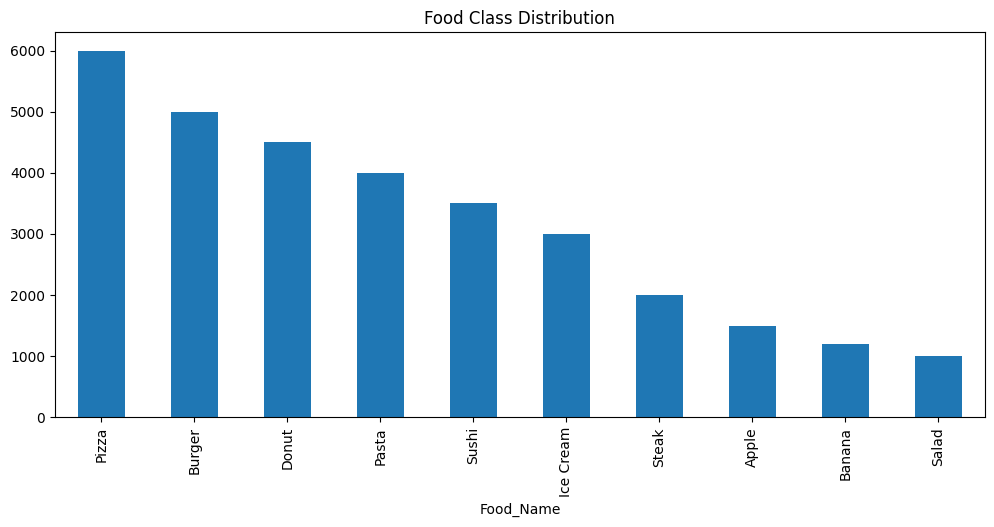

In [7]:
plt.figure(figsize=(12,5))
df['Food_Name'].value_counts().plot(kind='bar')
plt.title("Food Class Distribution")
plt.show()


In [8]:
print("Before removing dublicates:",df.shape)
df.drop_duplicates(inplace=True)
print("After removing duplicates:",df.shape)

Before removing dublicates: (31700, 16)
After removing duplicates: (31387, 16)


In [9]:
df.isnull().sum()

Calories              127
Protein               127
Fat                   127
Carbs                 127
Sugar                 127
Fiber                 127
Sodium                127
Cholesterol           127
Glycemic_Index        127
Water_Content         127
Serving_Size          127
Meal_Type               0
Preparation_Method      0
Is_Vegan                0
Is_Gluten_Free          0
Food_Name               0
dtype: int64

In [10]:
df.fillna(method='ffill', inplace=True)

In [11]:
for col in df.select_dtypes(include=['int64','float64']).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)


In [12]:
X = df.drop("Food_Name", axis=1)
y = df["Food_Name"]


In [13]:
X = pd.get_dummies(X, drop_first=True)


In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (25109, 19)
Testing shape: (6278, 19)


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")


Scaling completed.


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n{name}")
    print("Accuracy:", acc)



Logistic Regression
Accuracy: 0.9913985345651481

Decision Tree
Accuracy: 0.9853456514813634

Random Forest
Accuracy: 0.992035680152915

KNN
Accuracy: 0.9899649569926728

SVM
Accuracy: 0.9934692577253903

Gradient Boosting
Accuracy: 0.9928321121376235


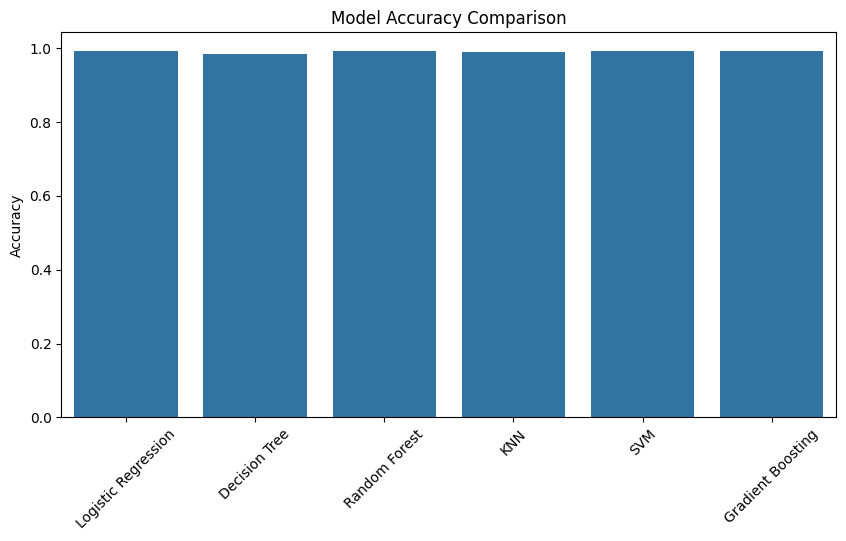

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


In [19]:
results


{'Logistic Regression': 0.9913985345651481,
 'Decision Tree': 0.9853456514813634,
 'Random Forest': 0.992035680152915,
 'KNN': 0.9899649569926728,
 'SVM': 0.9934692577253903,
 'Gradient Boosting': 0.9928321121376235}

In [20]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

best_model = SVC()
best_model.fit(X_train_scaled, y_train)

y_pred_best = best_model.predict(X_test_scaled)

print("Classification Report:\n")
print(classification_report(y_test, y_pred_best))


Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       297
           1       0.98      0.99      0.98       239
           2       0.99      0.99      0.99       988
           3       1.00      1.00      1.00       893
           4       1.00      1.00      1.00       594
           5       0.99      0.99      0.99       795
           6       0.99      0.99      0.99      1183
           7       1.00      0.99      1.00       199
           8       0.99      1.00      1.00       398
           9       1.00      1.00      1.00       692

    accuracy                           0.99      6278
   macro avg       0.99      0.99      0.99      6278
weighted avg       0.99      0.99      0.99      6278



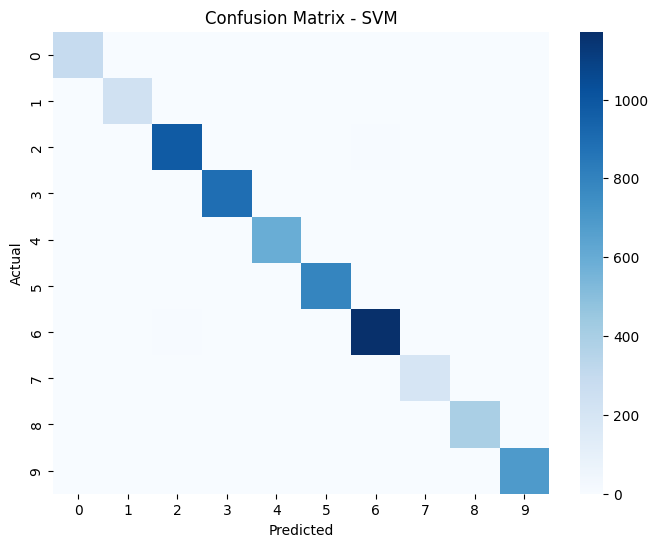

In [21]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [22]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


Cross Validation Scores: [0.99243329 0.99183592 0.99263242 0.99422541 0.99243179]
Mean CV Accuracy: 0.9927117655032456


In [23]:
from sklearn.decomposition import PCA

# Apply PCA (keep 95% variance)
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Reduced number of features after PCA:", X_train_pca.shape[1])


Original number of features: 19
Reduced number of features after PCA: 13


In [24]:
from sklearn.svm import SVC

svm_pca = SVC(random_state=42)
svm_pca.fit(X_train_pca, y_train)

pca_accuracy = svm_pca.score(X_test_pca, y_test)
print("SVM Accuracy after PCA:", pca_accuracy)


SVM Accuracy after PCA: 0.9894870978018477


In [25]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_scaled, y_train)

gb_accuracy = gb_model.score(X_test_scaled, y_test)
print("Gradient Boosting Accuracy:", gb_accuracy)


Gradient Boosting Accuracy: 0.9926728257406817


In [26]:
model_scores = {
    "Logistic Regression": 0.9913985345651481,
    "Decision Tree": 0.9848677922905383,
    "Random Forest": 0.9929913985345652,
    "KNN": 0.9899649569926728,
    "SVM": 0.9934692577253903,
    "Gradient Boosting": gb_accuracy
}

model_scores


{'Logistic Regression': 0.9913985345651481,
 'Decision Tree': 0.9848677922905383,
 'Random Forest': 0.9929913985345652,
 'KNN': 0.9899649569926728,
 'SVM': 0.9934692577253903,
 'Gradient Boosting': 0.9926728257406817}